# 匯入套件

In [5]:
import os
import torch
import torch.nn.functional as F
import pickle
import sys

sys.path.append('../')

from core.model import *
from core.train import *
from utils.checkpoint import *
from utils.util import *
from accelerate import Accelerator
import matplotlib.pyplot as plt
%matplotlib inline

# 模型參數

In [3]:
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

args = parse_args()

args.modeltype = 'TS_Text'
args.fp16 = True
args.num_train_epochs = 8
args.train_batch_size = 2
args.eval_batch_size = 8

args.notes_order = 'Last'
args.num_of_notes = 5
args.output_dir = "../run/TS_Text"
args.file_path = '../../../../datasets/mimic-iv/TS_Text'
args.task = 'ihm-48-notes'

args.layers = 1
args.embed_dim = 128
args.num_modalities = 2
args.num_labels = 2
args.tt_max = 48
args.num_heads = 8
args.embed_time = 64
args.kernel_size = 1

args.irregular_learn_emb_ts = 'mTAND'
args.irregular_learn_emb_text = 'mTAND'
args.irregular_learn_emb_cxr = 'mTAND'
args.irregular_learn_emb_ecg = 'mTAND'

args.cross_method = "moe"
args.gating_function = ["laplace"]
args.num_of_experts = [16, 5]
args.top_k = [4, 4]
args.disjoint_top_k = 2
args.hidden_size = 512
args.router_type = 'joint'

args.TS_mixup = True
args.mixup_level = 'batch'
args.reg_ts = True

# 視覺化 mTAND 注意力權重

../run/TS_Text/ihm-48-notes_TS_Text_TS_mTAND_64_Text_mTAND_64_layer1_moe_['laplace']_joint_[16, 5]_top_[4, 4]_batch_0.0004_8_8_128_1_2_512/f1/1.pth.tar


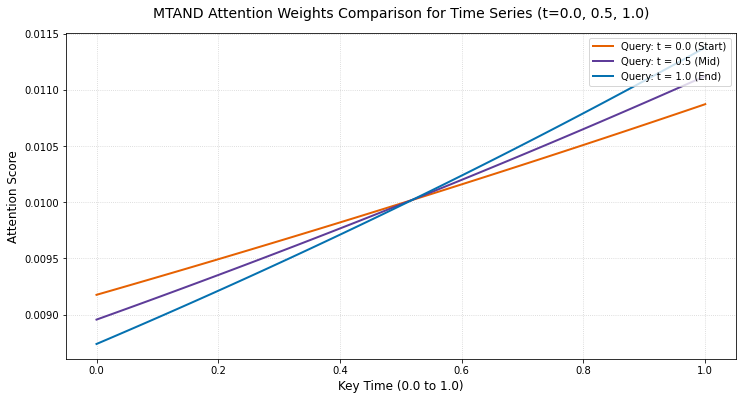

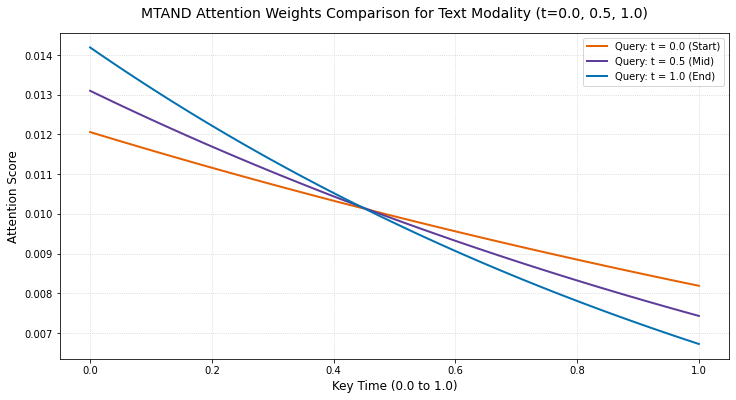

In [7]:
accelerator = Accelerator(cpu=args.cpu)

device = accelerator.device
os.makedirs(args.output_dir, exist_ok=True)

make_save_dir(args)

model = MULTCrossModel(args=args, device=device, orig_d_ts=30, orig_reg_d_ts=60, orig_d_txt=768, ts_seq_num=args.tt_max, text_seq_num=args.num_of_notes)
with open(os.path.join(args.file_path, f'scalers_{args.task}.pkl'), 'rb') as f:
    scalers = pickle.load(f)

model = accelerator.prepare(model)

rootdir = args.ck_file_path
seeds = [1]

for seed in seeds:
    for subdir, dirs, files in os.walk(rootdir):
        substr = subdir.split('/')[-1]
        if 'f1' not in substr:
            continue

        file = f'{seed}.pth.tar'
        file_path = os.path.join(subdir, file)
        print(file_path)
        checkpoint = torch.load(file_path, map_location=device)
        model.load_state_dict(checkpoint['network'])
        model.eval()

        with torch.no_grad():
            # 1. 定義 100 個 Key 時間點 (0 到 1 均勻分佈)
            key_times = torch.linspace(0.0, 1.0, steps=100, device=device).unsqueeze(1) # Shape: (100, 1)
            times_np = key_times.squeeze(1).cpu().numpy()
            times_np = 1 - times_np

            # 時間特徵轉換函數 (Time2Vec)
            def get_time_embedding(t):
                p_emb = model.periodic(t)
                l_emb = model.linear(t)
                return torch.cat([p_emb, l_emb], dim=-1)

            keys_emb = get_time_embedding(key_times) # Shape: (100, 64)
            
            # ----------------------------------------------------
            # 提取各模態的 Key 轉換矩陣 (來自 linears[1])
            # ----------------------------------------------------
            k_transformed_ts = model.time_attn_ts.linears[1](keys_emb) # Shape: (100, 64)
            d_k_ts = k_transformed_ts.size(-1)

            # 檢查模型是否包含文字模態，若有則提取文字的 Key 轉換
            has_text = hasattr(model, 'time_attn_text') and model.time_attn_text is not None
            if has_text:
                k_transformed_text = model.time_attn_text.linears[1](keys_emb) # Shape: (100, 64)
                d_k_text = k_transformed_text.size(-1)

            # 2. 定義三個想要測試的 Query 時間點
            queries = {
                't = 0.0 (Start)': torch.tensor([[0.0]], dtype=torch.float32, device=device),
                't = 0.5 (Mid)': torch.tensor([[0.5]], dtype=torch.float32, device=device),
                't = 1.0 (End)': torch.tensor([[1.0]], dtype=torch.float32, device=device)
            }

            # 設定色彩與圖表基礎設定
            colors = {'t = 0.0 (Start)': '#E66101', 't = 0.5 (Mid)': '#5E3C99', 't = 1.0 (End)': '#0571B0'}
            os.makedirs(os.path.join(args.ck_file_path, 'images'), exist_ok=True)

            # ====================================================
            # 繪製 1. 時間序列 (Time Series) 的 Attention Weights
            # ====================================================
            plt.figure(figsize=(12, 6))
            for label, q_time in queries.items():
                query_emb = get_time_embedding(q_time)
                q_transformed = model.time_attn_ts.linears[0](query_emb)
                
                scores = torch.matmul(q_transformed, k_transformed_ts.transpose(0, 1)) / (d_k_ts ** 0.5)
                attention_weights = F.softmax(scores, dim=-1).squeeze(0).cpu().numpy()
                
                plt.plot(times_np, attention_weights, label=f'Query: {label}', color=colors[label], linewidth=2)

            plt.title('MTAND Attention Weights Comparison for Time Series (t=0.0, 0.5, 1.0)', fontsize=14, pad=15)
            plt.xlabel('Key Time (0.0 to 1.0)', fontsize=12)
            plt.ylabel('Attention Score', fontsize=12)
            plt.grid(True, linestyle=':', alpha=0.6)
            plt.legend(loc='upper right', frameon=True)
            
            save_path_ts = os.path.join(args.ck_file_path, 'images', 'mtand_attention_ts.png')
            plt.savefig(save_path_ts, transparent=False, facecolor='white')
            plt.show()
            plt.close()

            # ====================================================
            # 繪製 2. 文字模態 (Text) 的 Attention Weights (新增部分)
            # ====================================================
            if has_text:
                plt.figure(figsize=(12, 6))
                for label, q_time in queries.items():
                    query_emb = get_time_embedding(q_time)
                    # 使用文字模態專屬的 linears[0]
                    q_transformed = model.time_attn_text.linears[0](query_emb)
                    
                    # 與文字模態轉換後的 Key 計算點積注意力
                    scores = torch.matmul(q_transformed, k_transformed_text.transpose(0, 1)) / (d_k_text ** 0.5)
                    attention_weights = F.softmax(scores, dim=-1).squeeze(0).cpu().numpy()
                    
                    plt.plot(times_np, attention_weights, label=f'Query: {label}', color=colors[label], linewidth=2)

                plt.title('MTAND Attention Weights Comparison for Text Modality (t=0.0, 0.5, 1.0)', fontsize=14, pad=15)
                plt.xlabel('Key Time (0.0 to 1.0)', fontsize=12)
                plt.ylabel('Attention Score', fontsize=12)
                plt.grid(True, linestyle=':', alpha=0.6)
                plt.legend(loc='upper right', frameon=True)
                
                save_path_text = os.path.join(args.ck_file_path, 'images', 'mtand_attention_text.png')
                plt.savefig(save_path_text, transparent=False, facecolor='white')
                plt.show()
                plt.close()